# Лабораторная работа: генеративные сети для музыки

**Часть:** посимвольная токенизация.  
**Модели:** RNN, LSTM, Transformer.  
**Данные:** музыка в формате ABC-нотации.

Идея: ABC-нотация — это текстовая запись музыки. Поэтому мелодию можно представить как последовательность символов:
`X`, `:`, `\n`, `K`, `C`, `|`, `A`, `B`, `c`, `z`, цифры длительностей и т.д.

На этой части работы сравниваются три генеративные модели, которые учатся предсказывать следующий символ по предыдущим символам.

## 1. Установка и импорт библиотек

В Google Colab первая ячейка может выполняться 1–2 минуты. Если PyTorch уже установлен, повторная установка не нужна.

In [1]:
# Для Colab обычно достаточно раскомментировать строку ниже:
# %pip install torch matplotlib tqdm music21 -q

import os
import re
import math
import time
import random
import zipfile
import urllib.request
from pathlib import Path
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## 2. Загрузка датасета

Используется Nottingham dataset с мелодиями в формате `.abc`.  
Если интернет в среде недоступен, можно вручную загрузить `.abc`-файлы в папку `data/nottingham`.

In [2]:
DATA_DIR = Path("data/nottingham")
DATA_DIR.mkdir(parents=True, exist_ok=True)

def download_nottingham_dataset(data_dir: Path = DATA_DIR) -> Path:
    """
    Скачивает Nottingham dataset с GitHub и распаковывает его.
    Если данные уже есть, повторно не скачивает.
    """
    existing_abc = list(data_dir.rglob("*.abc"))
    if existing_abc:
        print(f"ABC-файлы уже найдены: {len(existing_abc)}")
        return data_dir

    url = "https://github.com/jukedeck/nottingham-dataset/archive/refs/heads/master.zip"
    zip_path = Path("nottingham-dataset.zip")

    print("Скачиваю датасет...")
    urllib.request.urlretrieve(url, zip_path)

    print("Распаковываю...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_dir)

    zip_path.unlink(missing_ok=True)
    print("Готово.")
    return data_dir

try:
    download_nottingham_dataset()
except Exception as e:
    print("Не удалось скачать датасет автоматически:", repr(e))
    print("Можно загрузить .abc-файлы вручную в папку:", DATA_DIR.resolve())

Скачиваю датасет...
Распаковываю...
Готово.


In [3]:
def read_abc_corpus(data_dir: Path = DATA_DIR, min_len: int = 80) -> str:
    """
    Читает все .abc-файлы и склеивает их в один корпус.
    Короткие/пустые фрагменты отбрасываются.
    """
    paths = sorted(data_dir.rglob("*.abc"))
    texts = []

    for path in paths:
        try:
            txt = path.read_text(encoding="utf-8", errors="ignore")
            txt = txt.replace("\r\n", "\n").replace("\r", "\n")
            txt = txt.strip()
            if len(txt) >= min_len:
                texts.append(txt)
        except Exception:
            pass

    if not texts:
        # Минимальный fallback только для проверки кода.
        # Для настоящей лабораторной лучше использовать полноценный Nottingham dataset.
        texts = [
            "X:1\nT:Example tune\nM:4/4\nL:1/8\nK:C\nCDEF GABc|cBAG FEDC|C2E2G2c2|c4 z4|]\n",
            "X:2\nT:Small jig\nM:6/8\nL:1/8\nK:G\nGFG BAB|d2B BAG|GFG BAB|A2B cBA|]\n",
        ]

    corpus = "\n\n".join(texts)
    return corpus

raw_text = read_abc_corpus()
print("Длина корпуса в символах:", len(raw_text))
print("Первые 700 символов корпуса:")
print(raw_text[:700])

Длина корпуса в символах: 898495
Первые 700 символов корпуса:
X: 1
T:A and A's Waltz
% Nottingham Music Database
S:Mick Peat
M:3/4
L:1/4
K:G
e|:"G"d2B|"D"A3/2B/2c|"G"B2G|"D"A2e|"G"d2B|"D"A3/2B/2c|
M:2/4
"F"B=F|
M:3/4
"G"G2e:||:
"C"g2e|"Bb"=f2d|"F"c2A|=F2e|"C"g2e|"Bb"=f2d|
M:2/4
"F"cA|
M:3/4
 [1 "G"G2e:| [2"G"G2z||


X: 2
T:Barry's Favourite
% Nottingham Music Database
S:Mick Peat
M:2/2
K:D
A2|:"D"a3/2b/2a3/2g/2 f2(3def|"Em"g3/2a/2g3/2f/2 "A"e2A2|"D"f3/2g/2f3/2e/2 d2f2\
|"Em"B3/2c/2d3/2e/2 "A"c2A2|
"D"a3/2b/2a3/2g/2 f2(3def|"Em"g3/2a/2g3/2f/2 "A"e2A2|\
"D"f3/2g/2f3/2e/2 d3/2e/2f3/2A/2|"G"B3/2d/2"A"d3/2c/2 "D"d2A2:|
|:"G"B3/2A/2B3/2g/2 "D"d2A2|"Em"e3/2d/2e3/2f/2 "A"e2a2|\
"G"b3/2a/2(3gab "D"a3/2g/2(3fga|"E"f3/2e/2(3def "A"e2A2|
"G"B3/2A/2B3/2g/2 "D"d2A2|


## 3. Предобработка и посимвольная токенизация

При посимвольной токенизации каждый уникальный символ становится отдельным токеном.  
Например, символ `A`, символ `|`, перенос строки `\n`, цифра `2` и двоеточие `:` — это разные токены.

In [4]:
def normalize_abc_text(text: str) -> str:
    """
    Небольшая нормализация:
    - единый формат переносов строк;
    - удаление очень редких не-ASCII символов;
    - схлопывание слишком длинных пустых участков.
    """
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[^\x09\x0A\x0D\x20-\x7E]", "", text)
    text = re.sub(r"\n{4,}", "\n\n\n", text)
    return text.strip() + "\n"

text = normalize_abc_text(raw_text)

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi: Dict[str, int] = {ch: i for i, ch in enumerate(chars)}
itos: Dict[int, str] = {i: ch for ch, i in stoi.items()}

def encode(s: str) -> List[int]:
    return [stoi[ch] for ch in s if ch in stoi]

def decode(ids: List[int]) -> str:
    return "".join(itos[int(i)] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Размер словаря:", vocab_size)
print("Первые 100 символов словаря:")
print(chars[:100])
print("Train tokens:", len(train_data), "Val tokens:", len(val_data))

Размер словаря: 93
Первые 100 символов словаря:
['\n', ' ', '!', '"', '#', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~']
Train tokens: 808627 Val tokens: 89848


## 4. Батчи для обучения

Задача модели: по последовательности символов `x` предсказать следующий символ `y`.

Пример:
- вход: `X:1\nT`
- цель: `:1\nTi`

In [5]:
block_size = 128      # длина контекста
batch_size = 64       # размер батча

def get_batch(split: str) -> Tuple[torch.Tensor, torch.Tensor]:
    source = train_data if split == "train" else val_data
    ix = torch.randint(len(source) - block_size - 1, (batch_size,))
    x = torch.stack([source[i:i+block_size] for i in ix])
    y = torch.stack([source[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print("x shape:", xb.shape)
print("y shape:", yb.shape)
print("Пример x:")
print(decode(xb[0].tolist()[:100]))
print("Пример y:")
print(decode(yb[0].tolist()[:100]))

x shape: torch.Size([64, 128])
y shape: torch.Size([64, 128])
Пример x:
dBg "C"ecg|"G"dcB "D7"AGF|"G"G3 G2||


X: 118
T:Haste To The Wedding
% Nottingham Music Database
S:E
Пример y:
Bg "C"ecg|"G"dcB "D7"AGF|"G"G3 G2||


X: 118
T:Haste To The Wedding
% Nottingham Music Database
S:EF


## 5. Модели

Ниже три модели с одинаковой постановкой задачи:

1. **RNN** — базовая рекуррентная модель.
2. **LSTM** — рекуррентная модель с механизмом памяти.
3. **Transformer** — модель на self-attention, которая лучше работает с дальними зависимостями.

In [6]:
class CharRNNLanguageModel(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int = 128, hidden_dim: int = 256, num_layers: int = 2, cell_type: str = "rnn", dropout: float = 0.2):
        super().__init__()
        self.cell_type = cell_type.lower()
        self.embedding = nn.Embedding(vocab_size, emb_dim)

        if self.cell_type == "rnn":
            self.rnn = nn.RNN(
                input_size=emb_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0.0,
                batch_first=True,
            )
        elif self.cell_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=emb_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                dropout=dropout if num_layers > 1 else 0.0,
                batch_first=True,
            )
        else:
            raise ValueError("cell_type должен быть 'rnn' или 'lstm'")

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_dim, vocab_size)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor = None):
        x = self.embedding(idx)
        out, _ = self.rnn(x)
        out = self.dropout(out)
        logits = self.head(out)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.reshape(B*T, C), targets.reshape(B*T))

        return logits, loss


class CharTransformerLanguageModel(nn.Module):
    def __init__(self, vocab_size: int, block_size: int, emb_dim: int = 128, n_head: int = 4, n_layer: int = 3, ff_dim: int = 512, dropout: float = 0.2):
        super().__init__()
        self.block_size = block_size
        self.token_embedding = nn.Embedding(vocab_size, emb_dim)
        self.position_embedding = nn.Embedding(block_size, emb_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_head,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layer)
        self.ln_f = nn.LayerNorm(emb_dim)
        self.head = nn.Linear(emb_dim, vocab_size)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor = None):
        B, T = idx.shape
        if T > self.block_size:
            idx = idx[:, -self.block_size:]
            T = self.block_size

        token_emb = self.token_embedding(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding(pos)[None, :, :]
        x = token_emb + pos_emb

        # causal mask: текущая позиция не видит будущие символы
        causal_mask = torch.triu(torch.ones(T, T, device=idx.device), diagonal=1).bool()

        x = self.transformer(x, mask=causal_mask)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            targets = targets[:, -T:]
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.reshape(B*T, C), targets.reshape(B*T))

        return logits, loss


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


rnn_model = CharRNNLanguageModel(vocab_size, cell_type="rnn").to(device)
lstm_model = CharRNNLanguageModel(vocab_size, cell_type="lstm").to(device)
transformer_model = CharTransformerLanguageModel(vocab_size, block_size=block_size).to(device)

for name, model in [
    ("RNN", rnn_model),
    ("LSTM", lstm_model),
    ("Transformer", transformer_model),
]:
    print(name, "parameters:", count_parameters(model))

RNN parameters: 266205
LSTM parameters: 957405
Transformer parameters: 635357


## 6. Обучение моделей



Для более достойного результата в Colab лучше поставить `max_steps=2000–4000`.

In [7]:
@torch.no_grad()
def estimate_loss(model: nn.Module, eval_iters: int = 30) -> Dict[str, float]:
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out


def train_model(
    model: nn.Module,
    model_name: str,
    max_steps: int = 1200,
    eval_interval: int = 200,
    lr: float = 1e-3,
) -> List[Dict[str, float]]:
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = []
    start_time = time.time()

    print(f"\n=== Обучение {model_name} ===")
    for step in tqdm(range(1, max_steps + 1)):
        xb, yb = get_batch("train")
        _, loss = model(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if step == 1 or step % eval_interval == 0 or step == max_steps:
            losses = estimate_loss(model, eval_iters=20)
            record = {
                "step": step,
                "train_loss": losses["train"],
                "val_loss": losses["val"],
                "val_ppl": math.exp(min(losses["val"], 20)),
            }
            history.append(record)
            print(
                f"{model_name} | step {step:5d} | "
                f"train loss {record['train_loss']:.4f} | "
                f"val loss {record['val_loss']:.4f} | "
                f"val ppl {record['val_ppl']:.2f}"
            )

    print(f"Время обучения {model_name}: {time.time() - start_time:.1f} сек.")
    return history

In [8]:
# Можно уменьшить max_steps до 300–500 для быстрой проверки кода.
MAX_STEPS = 1200
EVAL_INTERVAL = 200

histories = {}

histories["RNN"] = train_model(
    rnn_model,
    "RNN",
    max_steps=MAX_STEPS,
    eval_interval=EVAL_INTERVAL,
    lr=1e-3,
)

histories["LSTM"] = train_model(
    lstm_model,
    "LSTM",
    max_steps=MAX_STEPS,
    eval_interval=EVAL_INTERVAL,
    lr=1e-3,
)

histories["Transformer"] = train_model(
    transformer_model,
    "Transformer",
    max_steps=MAX_STEPS,
    eval_interval=EVAL_INTERVAL,
    lr=5e-4,
)


=== Обучение RNN ===


  0%|          | 0/1200 [00:00<?, ?it/s]

RNN | step     1 | train loss 4.3224 | val loss 4.2712 | val ppl 71.61
RNN | step   200 | train loss 1.2637 | val loss 1.2383 | val ppl 3.45
RNN | step   400 | train loss 1.1287 | val loss 1.1397 | val ppl 3.13
RNN | step   600 | train loss 1.0840 | val loss 1.0828 | val ppl 2.95
RNN | step   800 | train loss 1.0335 | val loss 1.0445 | val ppl 2.84
RNN | step  1000 | train loss 1.0064 | val loss 1.0236 | val ppl 2.78
RNN | step  1200 | train loss 0.9692 | val loss 1.0074 | val ppl 2.74
Время обучения RNN: 454.5 сек.

=== Обучение LSTM ===


  0%|          | 0/1200 [00:00<?, ?it/s]

LSTM | step     1 | train loss 4.5081 | val loss 4.5015 | val ppl 90.15
LSTM | step   200 | train loss 1.3473 | val loss 1.3045 | val ppl 3.69
LSTM | step   400 | train loss 1.1146 | val loss 1.0904 | val ppl 2.98
LSTM | step   600 | train loss 1.0019 | val loss 0.9963 | val ppl 2.71
LSTM | step   800 | train loss 0.9278 | val loss 0.9488 | val ppl 2.58
LSTM | step  1000 | train loss 0.8744 | val loss 0.9168 | val ppl 2.50
LSTM | step  1200 | train loss 0.8341 | val loss 0.8665 | val ppl 2.38
Время обучения LSTM: 1450.6 сек.

=== Обучение Transformer ===


  0%|          | 0/1200 [00:00<?, ?it/s]

Transformer | step     1 | train loss 4.4194 | val loss 4.3611 | val ppl 78.34
Transformer | step   200 | train loss 1.8907 | val loss 1.7487 | val ppl 5.75
Transformer | step   400 | train loss 1.5167 | val loss 1.4578 | val ppl 4.30
Transformer | step   600 | train loss 1.3416 | val loss 1.2795 | val ppl 3.59
Transformer | step   800 | train loss 1.2319 | val loss 1.2071 | val ppl 3.34
Transformer | step  1000 | train loss 1.1838 | val loss 1.1608 | val ppl 3.19
Transformer | step  1200 | train loss 1.1286 | val loss 1.1122 | val ppl 3.04
Время обучения Transformer: 1910.8 сек.


## 7. Графики loss

По графику удобно сравнить, какая модель лучше обобщает данные.  
Обычно LSTM и Transformer должны быть стабильнее базовой RNN.

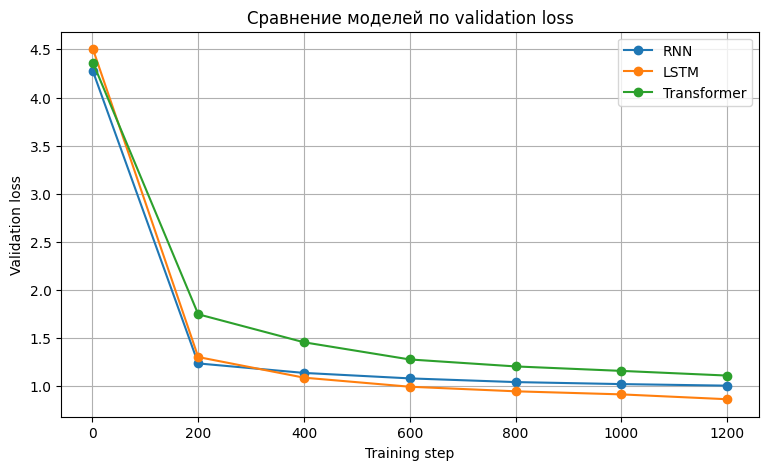

In [9]:
def plot_histories(histories: Dict[str, List[Dict[str, float]]]):
    plt.figure(figsize=(9, 5))

    for name, hist in histories.items():
        steps = [x["step"] for x in hist]
        val_loss = [x["val_loss"] for x in hist]
        plt.plot(steps, val_loss, marker="o", label=name)

    plt.xlabel("Training step")
    plt.ylabel("Validation loss")
    plt.title("Сравнение моделей по validation loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_histories(histories)

## 8. Генерация ABC-музыки

Модель генерирует новый текст посимвольно.  
Параметр `temperature` управляет случайностью:
- 0.6–0.8 — более аккуратно, но однообразнее;
- 1.0–1.2 — разнообразнее, но больше ошибок в синтаксисе ABC.

In [10]:
@torch.no_grad()
def generate(
    model: nn.Module,
    start_text: str = "X:1\nT:Generated tune\nM:4/4\nL:1/8\nK:C\n",
    max_new_tokens: int = 700,
    temperature: float = 0.8,
    top_k: int = 30,
) -> str:
    model.eval()

    context_ids = encode(start_text)
    idx = torch.tensor([context_ids], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / max(temperature, 1e-6)

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float("inf")

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_id), dim=1)

    model.train()
    return decode(idx[0].tolist())


samples = {}

for name, model in [
    ("RNN", rnn_model),
    ("LSTM", lstm_model),
    ("Transformer", transformer_model),
]:
    sample = generate(model, temperature=0.85, top_k=30)
    samples[name] = sample
    print("\n" + "="*80)
    print(name)
    print("="*80)
    print(sample[:1200])


RNN
X:1
T:Generated tune
M:4/4
L:1/8
K:C
"D"F2A FAG|"D"DFA d2e|"D"d3 A2d|"Bb"dgd edB|"D7"cBA GAF|"A7"GFG "A"A2:|
P:B
G/2A/2|"G"BGG DGB|"C"d2d dcd|"C"e2e d2c|"G"BGB GBd|"C"efg egg|"D"fd2 d2:|
P:B
e|"G"b2g bag|"D"aba "A7"gfe|"D"fef "A7"edc|"D"d2d d3|"G"dBd g2d|
"G"g2g gag|"D"fgf agf|"G"gfg "D7"fgf|"G"g3 "G"g2g|"Em"efg ded|"Em"edA BdB|"Am"cBF a3|"A"e2c cBA|"D"dcd "E7"d2d|"A"e2c "A7"e2g|
"D"agf agf|"Bm"bgd "G"g3||"D"a2f fgf|"D"add dff|"G"g2g dBG|"A7"AAF "E7"ABG|"A7"A2G A2B|"A"c2A ABc|"Dm"def "A"e2c|"D"d3 d2:|
P:B
A|"G"gfg "A7"a3|"A"a2g a2e|"G"dBG GAB|"G"d2d B3|
"A"c2c cBA|"G"G2B "D"A2f|
"C"gfe "G"dBG|
"G"g3 g2g|"Dm"f2f "A7"efe|"A7"eec cBA|"A"E^c e2d|"Em"g3 bgg|"D"agf f2f|\
"C"e2e "E"dcd|"A7"e2A A2^c|"B7"d3 B3|"G"g3 "D7"e2d|"G"d3 GBd|"G

LSTM
X:1
T:Generated tune
M:4/4
L:1/8
K:C
ag|:"Gm"f2B fcB|"C"g2e ece|"Dm"dcB "D7"F2D|"Gmb"b2b "Bm"a2g|"C"abg "C"g2e|
"F"fFA "C"edc|"C7"cde gfe|"G"dBG GAB|"C"cde "D7"ffg|"C"ecG "D7"AFA|"G"G2G G2:|
P:B
d|"C"ecc "G"Bcd|"C"Bea "C"edc|"G"BGB BdB|
"C"EcG "G"GGB|

## 9. Сохранение результатов

Сохраняем сгенерированные мелодии в `.abc`-файлы. Их можно открыть в онлайн ABC viewer или конвертировать в MIDI.

In [11]:
OUT_DIR = Path("generated_abc")
OUT_DIR.mkdir(exist_ok=True)

for name, sample in samples.items():
    path = OUT_DIR / f"generated_{name.lower()}.abc"
    path.write_text(sample, encoding="utf-8")
    print("Сохранено:", path)

Сохранено: generated_abc/generated_rnn.abc
Сохранено: generated_abc/generated_lstm.abc
Сохранено: generated_abc/generated_transformer.abc


## 10. Простейшая проверка качества

Для оценки используем следующие критерии
:

1. validation loss / perplexity;
2. наличие корректных ABC-заголовков `X:`, `T:`, `M:`, `L:`, `K:`;
3. наличие нотных символов и тактов `|`;
4. отсутствие полного распада в случайный набор символов;
5. субъективная музыкальность после прослушивания MIDI.

In [12]:
NOTE_CHARS = set("ABCDEFGabcdefgz")

def simple_abc_diagnostics(sample: str) -> Dict[str, object]:
    lines = sample.splitlines()
    result = {
        "has_X": any(line.startswith("X:") for line in lines),
        "has_T": any(line.startswith("T:") for line in lines),
        "has_M": any(line.startswith("M:") for line in lines),
        "has_L": any(line.startswith("L:") for line in lines),
        "has_K": any(line.startswith("K:") for line in lines),
        "bar_count": sample.count("|"),
        "note_symbol_count": sum(ch in NOTE_CHARS for ch in sample),
        "length": len(sample),
    }
    return result

for name, sample in samples.items():
    print(name, simple_abc_diagnostics(sample))

RNN {'has_X': True, 'has_T': True, 'has_M': True, 'has_L': True, 'has_K': True, 'bar_count': 59, 'note_symbol_count': 347, 'length': 737}
LSTM {'has_X': True, 'has_T': True, 'has_M': True, 'has_L': True, 'has_K': True, 'bar_count': 39, 'note_symbol_count': 292, 'length': 737}
Transformer {'has_X': True, 'has_T': True, 'has_M': True, 'has_L': True, 'has_K': True, 'bar_count': 25, 'note_symbol_count': 223, 'length': 737}


## 11. Сохранение моделей



In [14]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

torch.save({
    "model_state_dict": rnn_model.state_dict(),
    "stoi": stoi,
    "itos": itos,
    "block_size": block_size,
}, MODEL_DIR / "char_rnn_abc.pt")

torch.save({
    "model_state_dict": lstm_model.state_dict(),
    "stoi": stoi,
    "itos": itos,
    "block_size": block_size,
}, MODEL_DIR / "char_lstm_abc.pt")

torch.save({
    "model_state_dict": transformer_model.state_dict(),
    "stoi": stoi,
    "itos": itos,
    "block_size": block_size,
}, MODEL_DIR / "char_transformer_abc.pt")

print("Модели сохранены в папку:", MODEL_DIR.resolve())

Модели сохранены в папку: /content/models


## 13. Краткий вывод

Сгенерированные примеры подтверждают, что модели освоили базовый синтаксис ABC-нотации. Лучший баланс между метриками и структурой результата показала LSTM. RNN сгенерировала более простой, но достаточно связный ABC-текст. Transformer в данном запуске оказался менее удачным: его генерация формально похожа на ABC-нотацию, но структура мелодии менее стабильна.